In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import pickle
import numpy as np
import seaborn as sns
from scipy.stats import norm, laplace
from sklearn.metrics import r2_score
from scipy.stats import spearmanr, pearsonr
from matplotlib.ticker import FuncFormatter
from scipy.ndimage.filters import gaussian_filter1d
from scipy.stats import binned_statistic, gaussian_kde, kstest
from scipy.optimize import curve_fit

/tmp/ipykernel_2290654/3728421787.py:11: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


In [3]:
def marginal_prob_std(t, sigma_min, sigma_max):
    """Compute the standard deviation at time t."""
    return sigma_min * (sigma_max / sigma_min) ** t

In [3]:
from matplotlib import font_manager

font_dirs = ['/scratch4/jgray21/dxu39/miniforge3/envs/diffenergy/fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["mathtext.fontset"] = 'cm'

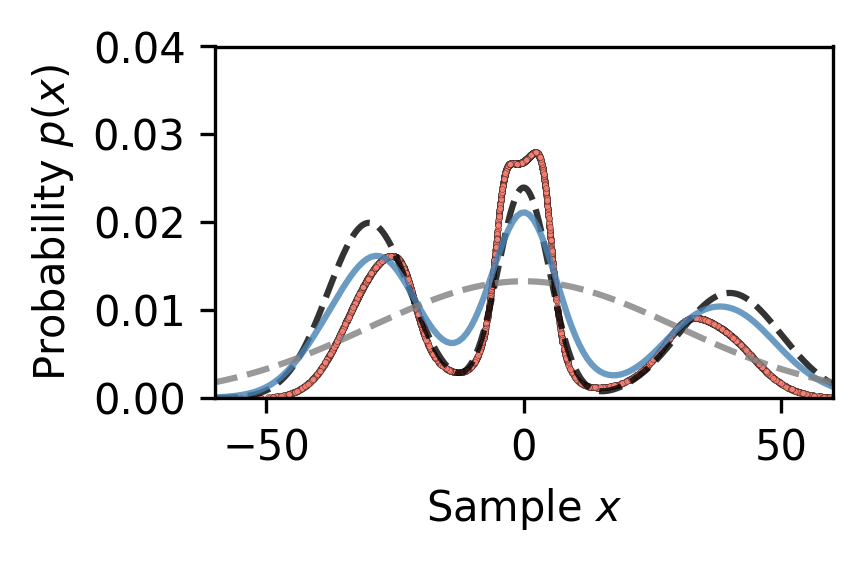

In [13]:
x = np.linspace(-60, 60, 500)
plt.figure(figsize=(3, 2))

# Define three Gaussian distributions
mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(x, loc=mu1, scale=b1) + w2 * norm.pdf(x, loc=mu2, scale=b2) + w3 * norm.pdf(x, loc=mu3, scale=b3)
plt.plot(x, gaussian_pdf, 'k', linestyle='--', alpha=0.8, label="Training data distribution, $P_0(x_0)$", zorder = 0)
#plt.fill_between(x, gaussian_pdf, color='pink', alpha=0.6)

# Plot Gaussian noise at t=1
sigma_min, sigma_max = 0.1, 30.0  # Define sigma limits
sigma = marginal_prob_std(1, sigma_min, sigma_max)
gaussian = norm.pdf(x, 0, sigma)  # Zero mean, std = sigma_t1
plt.plot(x, gaussian, color='gray', linestyle='dashed', alpha=0.8, label="Prior distribution, $P_1(x_1)$", zorder = 2)
#plt.fill_between(x, gaussian, color='green', alpha=0.2)

# Plot the samples data
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
# filename_1 = path + 'trinormal.csv'
filename_1 = '../../sample_results/trinormal_1d.csv'
# df = pd.read_csv(filename_1, index_col=0)
df = pd.read_csv(filename_1, index_col=0)
samples_1 = df.values.flatten()
sns.kdeplot(samples_1, color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)

# Load the flowtime
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
# filename_2 = path + 'flowtime_trinormal.csv'
# df = pd.read_csv(filename_2, usecols=[0])  
filename_2 = '../../likelihood_results/trinormal_1d_nll_flowtime_euler.csv'
df = pd.read_csv(filename_2)  
samples = df.iloc[:,1].values.flatten()
probability_1 = np.exp(-1.05 * samples)
plt.scatter(samples_1[:5000], probability_1[:5000], color='salmon', label="Recovered distribution from FlowTime Integral", s=2, linewidth=0.1, edgecolors=(0.1, 0.1, 0.1), alpha=0.8, zorder=-1)#, linewidth=0.2, edgecolors='k', zorder = -1)

# Load the difftime
#path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
#filename_2 = path + 'difftime_trinormal.csv'
#df = pd.read_csv(filename_2, usecols=[1])  
#samples = df.iloc[:,0].values.flatten()
#probability_2 = np.exp(-samples)
#plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=10)

# Load the diffspace
#path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
#filename_2 = path + 'diffspace_trinormal.csv'
#df = pd.read_csv(filename_2, usecols=[1])  
#samples = df.iloc[:,0].values.flatten()
#probability_2 = np.exp(-samples)
#plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=10)

#for spine in plt.gca().spines.values():
#spine.set_visible(False)

# Labels and title
plt.xlabel("Sample $x$")
plt.ylabel("Probability $p(x)$")
plt.xlim(-60,60)
plt.ylim(0, 0.04)
plt.grid(False)
plt.tight_layout()
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)
plt.yticks([0.00, 0.01, 0.02, 0.03, 0.04])
formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.gcf().set_dpi(300)
plt.savefig('flowtime_p_v_t.png', dpi=300)

In [5]:
mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_cdf =lambda x: (w1 * norm.cdf(x, loc=mu1, scale=b1) + w2 * norm.cdf(x, loc=mu2, scale=b2) + w3 * norm.cdf(x, loc=mu3, scale=b3))
res = kstest(samples_1, gaussian_cdf)

In [6]:
res

KstestResult(statistic=0.03860046922022853, pvalue=2.2075230530176686e-13, statistic_location=37.72451, statistic_sign=1)

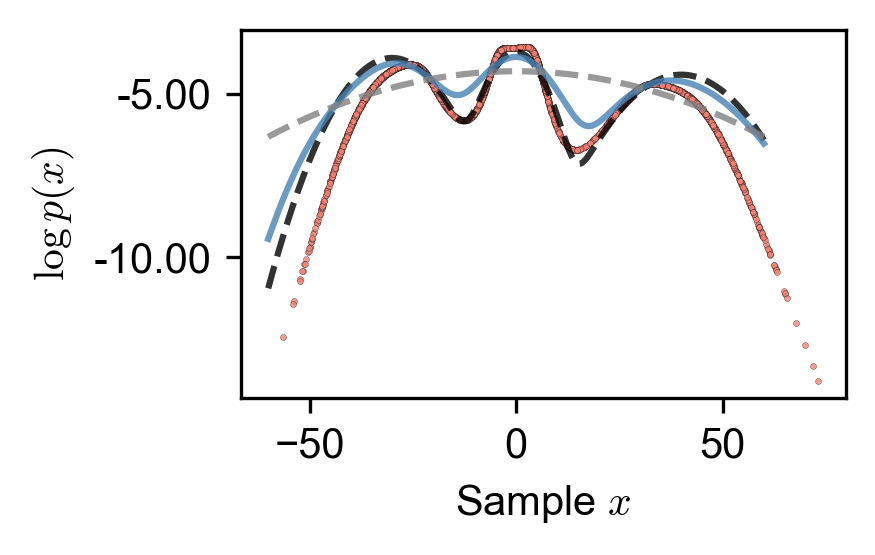

In [7]:
x = np.linspace(-60, 60, 500)
plt.figure(figsize=(3, 2))

# Define three Gaussian distributions
mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(x, loc=mu1, scale=b1) + w2 * norm.pdf(x, loc=mu2, scale=b2) + w3 * norm.pdf(x, loc=mu3, scale=b3)
plt.plot(x, np.log(gaussian_pdf), 'k', linestyle='--', alpha=0.8, label="Training data distribution, $P_0(x_0)$", zorder = 0)
#plt.fill_between(x, gaussian_pdf, color='pink', alpha=0.6)

# Plot Gaussian noise at t=1
sigma_min, sigma_max = 0.1, 30.0  # Define sigma limits
sigma = marginal_prob_std(1, sigma_min, sigma_max)
gaussian = norm.pdf(x, 0, sigma)  # Zero mean, std = sigma_t1
plt.plot(x, np.log(gaussian), color='gray', linestyle='dashed', alpha=0.8, label="Prior distribution, $P_1(x_1)$", zorder = 2)
#plt.fill_between(x, gaussian, color='green', alpha=0.2)

# Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df = pd.read_csv(filename_1, index_col=0)
samples_1 = df.values.flatten()
# sns.kdeplot(samples_1, color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)
gkde = gaussian_kde(samples_1, bw_method='silverman')
plt.plot(x, np.log(gkde(x)), color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)

# Load the flowtime
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'flowtime_trinormal.csv'
df = pd.read_csv(filename_2, usecols=[0])  
samples = df.iloc[:,0].values.flatten()
probability_1 = np.exp(-1.05 * samples)
plt.scatter(samples_1[:5000], np.log(probability_1[:5000]), color='salmon', label="Recovered distribution from FlowTime Integral", s=2, linewidth=0.1, edgecolors=(0.1, 0.1, 0.1), alpha=0.8, zorder=-1)#, linewidth=0.2, edgecolors='k', zorder = -1)

# Load the difftime
#path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
#filename_2 = path + 'difftime_trinormal.csv'
#df = pd.read_csv(filename_2, usecols=[1])  
#samples = df.iloc[:,0].values.flatten()
#probability_2 = np.exp(-samples)
#plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=10)

# Load the diffspace
#path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
#filename_2 = path + 'diffspace_trinormal.csv'
#df = pd.read_csv(filename_2, usecols=[1])  
#samples = df.iloc[:,0].values.flatten()
#probability_2 = np.exp(-samples)
#plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=10)

#for spine in plt.gca().spines.values():
#spine.set_visible(False)

# Labels and title
plt.xlabel("Sample $x$")
plt.ylabel("$\log p(x)$")
# plt.xlim(-60,60)
# plt.ylim(0, 0.04)
plt.grid(False)
plt.tight_layout()
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)
# plt.yticks([0.00, 0.01, 0.02, 0.03, 0.04])
formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.gcf().set_dpi(300)
# plt.savefig('flowtime_logp_v_t.png', dpi=300)

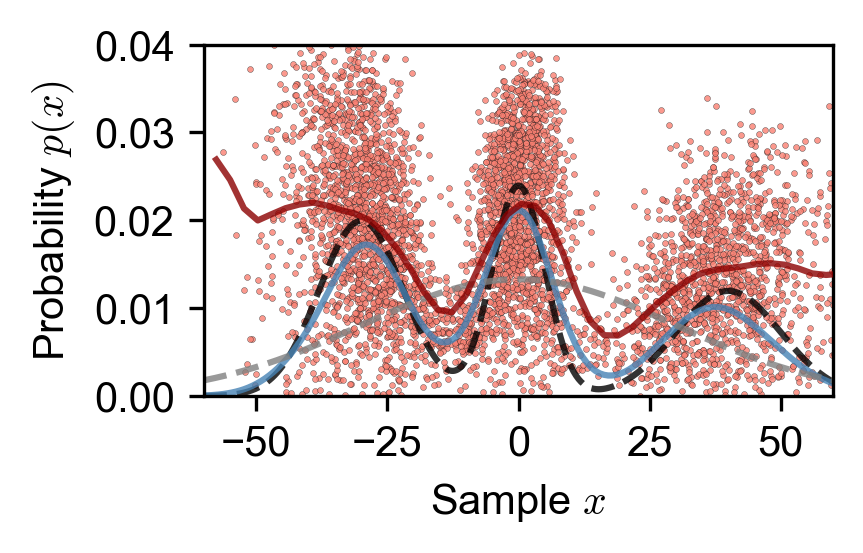

In [60]:
x = np.linspace(-60, 60, 500)
plt.figure(figsize=(3, 2))

# Define three Gaussian distributions
mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(x, loc=mu1, scale=b1) + w2 * norm.pdf(x, loc=mu2, scale=b2) + w3 * norm.pdf(x, loc=mu3, scale=b3)
plt.plot(x, gaussian_pdf, 'k', linestyle='--', alpha=0.8, label="Training data distribution, $P_0(x_0)$", zorder = 0)
#plt.fill_between(x, gaussian_pdf, color='pink', alpha=0.6)

# Plot Gaussian noise at t=1
sigma_min, sigma_max = 0.1, 30.0  # Define sigma limits
sigma = marginal_prob_std(1, sigma_min, sigma_max)
gaussian = norm.pdf(x, 0, sigma)  # Zero mean, std = sigma_t1
plt.plot(x, gaussian, color='gray', linestyle='dashed', alpha=0.8, label="Prior distribution, $P_1(x_1)$", zorder = 2)
#plt.fill_between(x, gaussian, color='green', alpha=0.2)

# Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df = pd.read_csv(filename_1, index_col=0)
samples_1 = df.values.flatten()
sns.kdeplot(samples_1, color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)

# # Load the flowtime
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
# filename_2 = path + 'flowtime_trinormal.csv'
# df = pd.read_csv(filename_2, usecols=[0])  
# samples = df.iloc[:,0].values.flatten()
# probability_1 = np.exp(-1.05 * samples)
# plt.scatter(samples_1, probability_1, color='orange', label="Recovered distribution from FlowTime Integral", s=1)

# Load the difftime
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'difftime_trinormal.csv'
df = pd.read_csv(filename_2, usecols=[1])  
samples = df.iloc[:,0].values.flatten()
probability_2 = np.exp(-samples)
plt.scatter(samples_1[:5000], probability_2[:5000], color='salmon', label="exp(-samples)", s=2, linewidth=0.1, edgecolors=(0.1, 0.1, 0.1), alpha=0.8, zorder=-1)

clamp_index = np.where(probability_2 < 0.04)[0]
prob_mean, bin_edges, binnumber = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='mean', bins=50)
prob_std = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='std', bins=50).statistic
prob_mean = gaussian_filter1d(prob_mean, sigma=1.0)
prob_std = gaussian_filter1d(prob_std, sigma=1.0)
upper = prob_mean + prob_std
lower = prob_mean - prob_std
bin_width = (bin_edges[1] - bin_edges[0])
bin_centers = bin_edges[1:] - bin_width/2

plt.plot(bin_centers, prob_mean, color='darkred', zorder = 3, alpha=0.8)
# plt.plot(bin_centers, upper, color='darkred', linestyle='dashed', linewidth=1.15, zorder = 3, alpha=0.8)
# plt.plot(bin_centers, lower, color='darkred', linestyle='dashed', linewidth=1.15, zorder = 3, alpha=0.8)
# plt.fill_between(bin_centers, upper, lower, color='crimson', alpha=0.1, zorder = 0)

# Load the diffspace
#path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
#filename_2 = path + 'diffspace_trinormal.csv'
#df = pd.read_csv(filename_2, usecols=[1])  
#samples = df.iloc[:,0].values.flatten()
#probability_2 = np.exp(-samples)
#plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=10)

#for spine in plt.gca().spines.values():
#spine.set_visible(False)

# Labels and title
plt.xlabel("Sample $x$")
plt.ylabel("Probability $p(x)$")
plt.xlim(-60,60)
plt.ylim(0, 0.04)
plt.grid(False)
plt.tight_layout()
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)
plt.yticks([0.00, 0.01, 0.02, 0.03, 0.04])
formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.gcf().set_dpi(300)
plt.savefig('difftime_p_v_t.png', dpi=300)

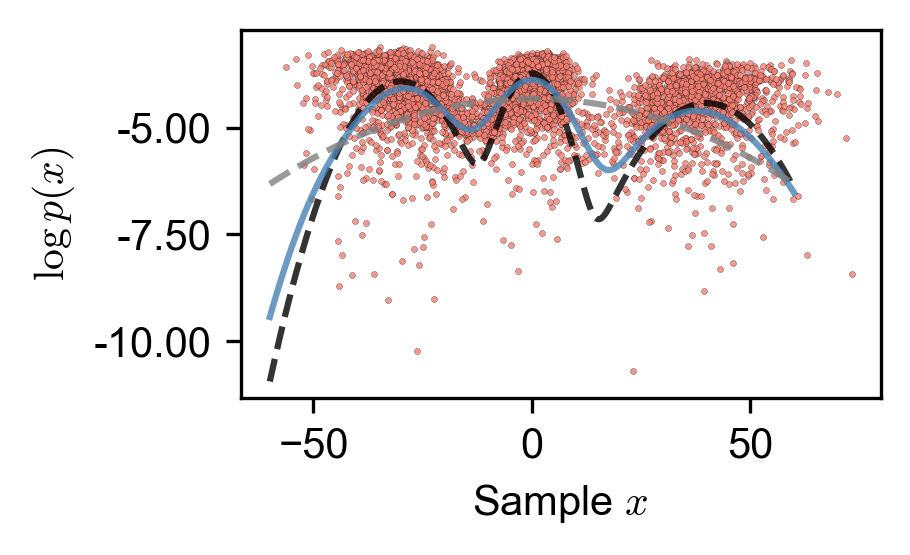

In [21]:
x = np.linspace(-60, 60, 500)
plt.figure(figsize=(3, 2))

# Define three Gaussian distributions
mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(x, loc=mu1, scale=b1) + w2 * norm.pdf(x, loc=mu2, scale=b2) + w3 * norm.pdf(x, loc=mu3, scale=b3)
plt.plot(x, np.log(gaussian_pdf), 'k', linestyle='--', alpha=0.8, label="Training data distribution, $P_0(x_0)$", zorder = 0)
#plt.fill_between(x, gaussian_pdf, color='pink', alpha=0.6)

# Plot Gaussian noise at t=1
sigma_min, sigma_max = 0.1, 30.0  # Define sigma limits
sigma = marginal_prob_std(1, sigma_min, sigma_max)
gaussian = norm.pdf(x, 0, sigma)  # Zero mean, std = sigma_t1
plt.plot(x, np.log(gaussian), color='gray', linestyle='dashed', alpha=0.8, label="Prior distribution, $P_1(x_1)$", zorder = 2)
#plt.fill_between(x, gaussian, color='green', alpha=0.2)

# # Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df = pd.read_csv(filename_1, index_col=0)
samples_1 = df.values.flatten()
# sns.kdeplot(samples_1, color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)
gkde = gaussian_kde(samples_1, bw_method='silverman')
plt.plot(x, np.log(gkde(x)), color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)

# # Load the flowtime
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
# filename_2 = path + 'flowtime_trinormal.csv'
# df = pd.read_csv(filename_2, usecols=[0])  
# samples = df.iloc[:,0].values.flatten()
# probability_1 = np.exp(-1.05 * samples)
# plt.scatter(samples_1, probability_1, color='orange', label="Recovered distribution from FlowTime Integral", s=1)

# Load the difftime
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'difftime_trinormal.csv'
df = pd.read_csv(filename_2, usecols=[1])  
samples = df.iloc[:,0].values.flatten()
probability_2 = np.exp(-samples)
plt.scatter(samples_1[:5000], np.log(probability_2[:5000]), color='salmon', label="exp(-samples)", s=2, linewidth=0.1, edgecolors=(0.1, 0.1, 0.1), alpha=0.8, zorder=-1)

# clamp_index = np.where(probability_2 < 0.04)[0]
# prob_mean, bin_edges, binnumber = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='mean', bins=50)
# prob_std = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='std', bins=50).statistic
# prob_mean = gaussian_filter1d(prob_mean, sigma=1.0)
# prob_std = gaussian_filter1d(prob_std, sigma=1.0)
# upper = prob_mean + prob_std
# lower = prob_mean - prob_std
# bin_width = (bin_edges[1] - bin_edges[0])
# bin_centers = bin_edges[1:] - bin_width/2

# plt.plot(bin_centers, prob_mean, color='darkred', zorder = 3, alpha=0.8)
# plt.fill_between(bin_centers, upper, lower, color='crimson', alpha=0.2, zorder = 0)

# Load the diffspace
#path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
#filename_2 = path + 'diffspace_trinormal.csv'
#df = pd.read_csv(filename_2, usecols=[1])  
#samples = df.iloc[:,0].values.flatten()
#probability_2 = np.exp(-samples)
#plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=10)

#for spine in plt.gca().spines.values():
#spine.set_visible(False)

# Labels and title
plt.xlabel("Sample $x$")
plt.ylabel("$\log p(x)$")
# plt.xlim(-60,60)
# plt.ylim(0, 0.04)
plt.grid(False)
plt.tight_layout()
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)
# plt.yticks([0.00, 0.01, 0.02, 0.03, 0.04])
formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.gcf().set_dpi(300)
# plt.savefig('difftime_p_v_t.png', dpi=300)

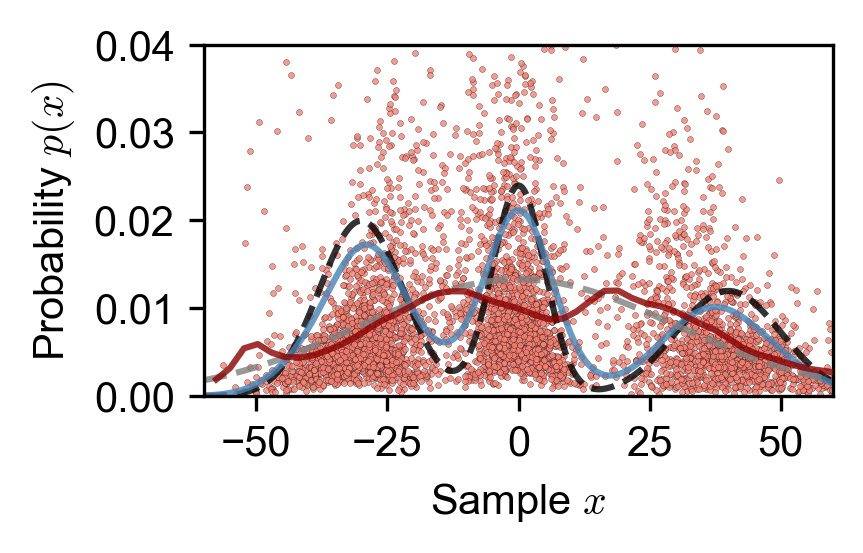

In [59]:
x = np.linspace(-60, 60, 500)
plt.figure(figsize=(3, 2))

# Define three Gaussian distributions
mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(x, loc=mu1, scale=b1) + w2 * norm.pdf(x, loc=mu2, scale=b2) + w3 * norm.pdf(x, loc=mu3, scale=b3)
plt.plot(x, gaussian_pdf, 'k', linestyle='--', alpha=0.8, label="Training data distribution, $P_0(x_0)$", zorder = 0)
#plt.fill_between(x, gaussian_pdf, color='pink', alpha=0.6)

# Plot Gaussian noise at t=1
sigma_min, sigma_max = 0.1, 30.0  # Define sigma limits
sigma = marginal_prob_std(1, sigma_min, sigma_max)
gaussian = norm.pdf(x, 0, sigma)  # Zero mean, std = sigma_t1
plt.plot(x, gaussian, color='gray', linestyle='dashed', alpha=0.8, label="Prior distribution, $P_1(x_1)$", zorder = 2)
#plt.fill_between(x, gaussian, color='green', alpha=0.2)

# Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df = pd.read_csv(filename_1, index_col=0)
samples_1 = df.values.flatten()
sns.kdeplot(samples_1, color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)

# # Load the flowtime
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
# filename_2 = path + 'flowtime_trinormal.csv'
# df = pd.read_csv(filename_2, usecols=[0])  
# samples = df.iloc[:,0].values.flatten()
# probability_1 = np.exp(-1.05 * samples)
# plt.scatter(samples_1, probability_1, color='orange', label="Recovered distribution from FlowTime Integral", s=1)

# # Load the difftime
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
# filename_2 = path + 'difftime_trinormal.csv'
# df = pd.read_csv(filename_2, usecols=[1])  
# samples = df.iloc[:,0].values.flatten()
# probability_2 = np.exp(-samples)
# plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=1)

# Load the diffspace
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'diffspace_trinormal.csv'
df = pd.read_csv(filename_2, usecols=[1])  
samples = df.iloc[:,0].values.flatten()
probability_2 = np.exp(-samples)
plt.scatter(samples_1[:5000], probability_2[:5000], color='salmon', label="exp(-samples)", s=2, linewidth=0.1, edgecolors=(0.1, 0.1, 0.1), alpha=0.8, zorder=-1)

clamp_index = np.where(probability_2 < 0.04)[0]
prob_mean, bin_edges, binnumber = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='mean', bins=50)
prob_std = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='std', bins=50).statistic
prob_mean = gaussian_filter1d(prob_mean, sigma=1.0)
prob_std = gaussian_filter1d(prob_std, sigma=1.0)
upper = prob_mean + prob_std
lower = prob_mean - prob_std
bin_width = (bin_edges[1] - bin_edges[0])
bin_centers = bin_edges[1:] - bin_width/2

plt.plot(bin_centers, prob_mean, color='darkred', zorder = 3, alpha=0.8)
# plt.fill_between(bin_centers, upper, lower, color='crimson', alpha=0.1, zorder = -1)
# plt.plot(bin_centers, upper, color='darkred', linestyle='dashed', linewidth=1.15, zorder = 3, alpha=0.8)
# plt.plot(bin_centers, lower, color='darkred', linestyle='dashed', linewidth=1.15, zorder = 3, alpha=0.8)

#for spine in plt.gca().spines.values():
#spine.set_visible(False)

# Labels and title
plt.xlabel("Sample $x$")
plt.ylabel("Probability $p(x)$")
plt.xlim(-60,60)
plt.ylim(0, 0.04)
plt.grid(False)
plt.tight_layout()
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)
plt.yticks([0.00, 0.01, 0.02, 0.03, 0.04])
formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.gcf().set_dpi(300)
plt.savefig('diffspace_p_v_t.png', dpi=300)

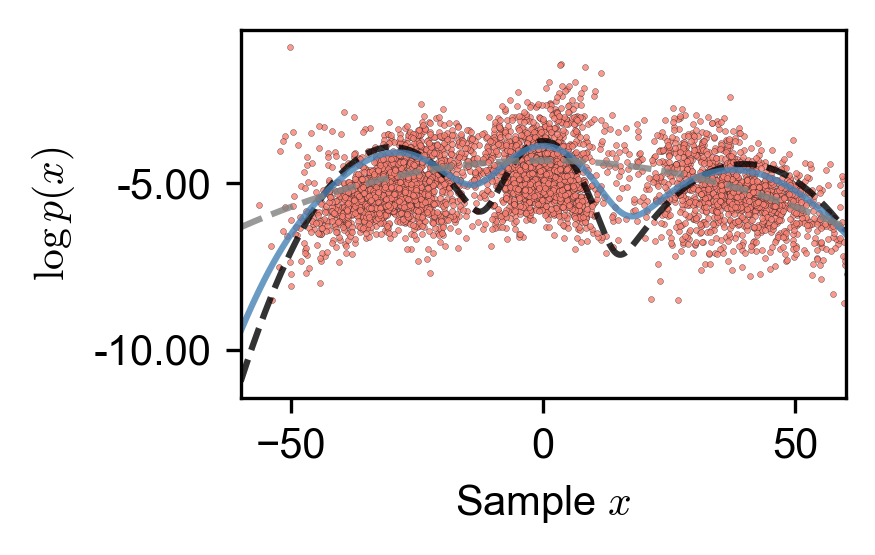

In [23]:
x = np.linspace(-60, 60, 500)
plt.figure(figsize=(3, 2))

# Define three Gaussian distributions
mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(x, loc=mu1, scale=b1) + w2 * norm.pdf(x, loc=mu2, scale=b2) + w3 * norm.pdf(x, loc=mu3, scale=b3)
plt.plot(x, np.log(gaussian_pdf), 'k', linestyle='--', alpha=0.8, label="Training data distribution, $P_0(x_0)$", zorder = 0)
#plt.fill_between(x, gaussian_pdf, color='pink', alpha=0.6)

# Plot Gaussian noise at t=1
sigma_min, sigma_max = 0.1, 30.0  # Define sigma limits
sigma = marginal_prob_std(1, sigma_min, sigma_max)
gaussian = norm.pdf(x, 0, sigma)  # Zero mean, std = sigma_t1
plt.plot(x, np.log(gaussian), color='gray', linestyle='dashed', alpha=0.8, label="Prior distribution, $P_1(x_1)$", zorder = 2)
#plt.fill_between(x, gaussian, color='green', alpha=0.2)

# # Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df = pd.read_csv(filename_1, index_col=0)
samples_1 = df.values.flatten()
# sns.kdeplot(samples_1, color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)
gkde = gaussian_kde(samples_1, bw_method='silverman')
plt.plot(x, np.log(gkde(x)), color='steelblue', alpha=0.8, label="Density estimate from generated samples", zorder = 1)

# # Load the flowtime
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
# filename_2 = path + 'flowtime_trinormal.csv'
# df = pd.read_csv(filename_2, usecols=[0])  
# samples = df.iloc[:,0].values.flatten()
# probability_1 = np.exp(-1.05 * samples)
# plt.scatter(samples_1, probability_1, color='orange', label="Recovered distribution from FlowTime Integral", s=1)

# # Load the difftime
# path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
# filename_2 = path + 'difftime_trinormal.csv'
# df = pd.read_csv(filename_2, usecols=[1])  
# samples = df.iloc[:,0].values.flatten()
# probability_2 = np.exp(-samples)
# plt.scatter(samples_1, probability_2, color='orange', label="exp(-samples)", s=1)

# Load the diffspace
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'diffspace_trinormal.csv'
df = pd.read_csv(filename_2, usecols=[1])  
samples = df.iloc[:,0].values.flatten()
probability_2 = np.exp(-samples)
plt.scatter(samples_1[:5000], np.log(probability_2[:5000]), color='salmon', label="exp(-samples)", s=2, linewidth=0.1, edgecolors=(0.1, 0.1, 0.1), alpha=0.8, zorder=-1)

# clamp_index = np.where(probability_2 < 0.04)[0]
# prob_mean, bin_edges, binnumber = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='mean', bins=50)
# prob_std = binned_statistic(samples_1[clamp_index], probability_2[clamp_index], statistic='std', bins=50).statistic
# prob_mean = gaussian_filter1d(prob_mean, sigma=1.0)
# prob_std = gaussian_filter1d(prob_std, sigma=1.0)
# upper = prob_mean + prob_std
# lower = prob_mean - prob_std
# bin_width = (bin_edges[1] - bin_edges[0])
# bin_centers = bin_edges[1:] - bin_width/2

# plt.plot(bin_centers, prob_mean, color='darkred', zorder = 3, alpha=0.8)
# plt.fill_between(bin_centers, upper, lower, color='crimson', alpha=0.2, zorder = 0)

#for spine in plt.gca().spines.values():
#spine.set_visible(False)

# Labels and title
plt.xlabel("Sample $x$")
plt.ylabel("$\log p(x)$")
plt.xlim(-60,60)
# plt.ylim(0, 0.04)
plt.grid(False)
plt.tight_layout()
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)
# plt.yticks([0.00, 0.01, 0.02, 0.03, 0.04])
formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.gcf().set_dpi(300)
# plt.savefig('diffspace_p_v_t.png', dpi=300)

Pearson Correlation: 0.8647
P-value: 0.0000e+00


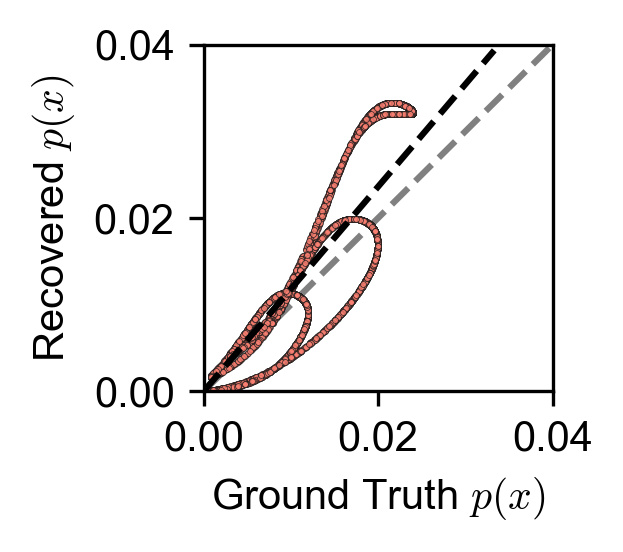

In [47]:
# Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df_1 = pd.read_csv(filename_1, index_col=0)
samples_1 = df_1.values.flatten()

path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'flowtime_trinormal.csv'
df_2 = pd.read_csv(filename_2, usecols=['bpd'])  
logp = df_2['bpd'].values.flatten()
probability_1 = np.exp(-logp)

mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(samples_1, loc=mu1, scale=b1) + w2 * norm.pdf(samples_1, loc=mu2, scale=b2) + w3 * norm.pdf(samples_1, loc=mu3, scale=b3)

# sorted_indices = np.argsort(samples_1)
# samples_1_sorted = samples_1[sorted_indices]
# gaussian_pdf_sorted = gaussian_pdf[sorted_indices]
# probability_1_sorted = probability_1[sorted_indices]

# # Subsample for clarity
# gaussian_pdf_sub = gaussian_pdf_sorted[::10]
# probability_sub = probability_1_sorted[::10]

plt.figure(figsize=(1.5, 1.5))
plt.scatter(gaussian_pdf[:5000], probability_1[:5000], color='salmon', edgecolors=(0.1, 0.1, 0.1), linewidth=0.2, s=2, label="Scatter", alpha=0.8, zorder=1)

# Draw y = x line
plt.plot([0, 0.4], [0, 0.4], color='gray', linestyle='--', label='y = x', zorder=0)

def line_through_origin(x, a):
    return a * x

# Fit the model
params, pcov, infodict, mesg, ier  = curve_fit(line_through_origin, gaussian_pdf, probability_1, full_output=True)
a = params[0]

# Draw y = ax line
min_val = min(gaussian_pdf.min(), probability_1.min())
max_val = max(gaussian_pdf.max(), probability_1.max())
plt.plot([min_val, max_val], [a*min_val, a*max_val], color='k', linestyle='--', label=f'y = {a:.2f}x')


# Example
corr, p_value = pearsonr(gaussian_pdf, probability_1)
print(f"Pearson Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

plt.xlim([0, 0.04])
plt.ylim([0, 0.04])
plt.yticks([0, 0.02, 0.04])
plt.xticks([0, 0.02, 0.04])
plt.xlabel("Ground Truth $p(x)$")
plt.ylabel("Recovered $p(x)$")
plt.gcf().set_dpi(300)
# plt.savefig("flowt_gt.png", dpi=300)
plt.savefig('flowtime_gt.png', dpi=300, bbox_inches='tight')

Fitted slope: 1.1644
Pearson Correlation: 0.3642
P-value: 2.1067e-311


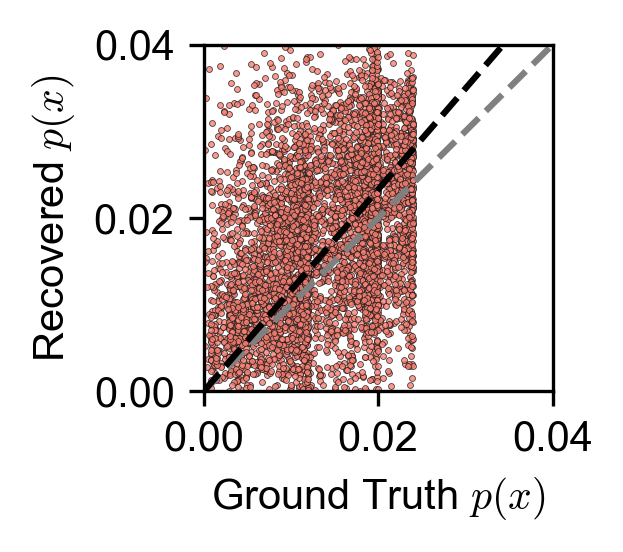

In [48]:
# Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df_1 = pd.read_csv(filename_1, index_col=0)
samples_1 = df_1.values.flatten()

path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'difftime_trinormal.csv'
df_2 = pd.read_csv(filename_2, usecols=['bpd'])  
logp = df_2['bpd'].values.flatten()
probability_1 = np.exp(-logp)

mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(samples_1, loc=mu1, scale=b1) + w2 * norm.pdf(samples_1, loc=mu2, scale=b2) + w3 * norm.pdf(samples_1, loc=mu3, scale=b3)

# sorted_indices = np.argsort(samples_1)
# samples_1_sorted = samples_1[sorted_indices]
# gaussian_pdf_sorted = gaussian_pdf[sorted_indices]
# probability_1_sorted = probability_1[sorted_indices]

# # Subsample for clarity
# gaussian_pdf_sub = gaussian_pdf_sorted[::10]
# probability_sub = probability_1_sorted[::10]

plt.figure(figsize=(1.5,1.5))
plt.scatter(gaussian_pdf[:5000], probability_1[:5000], color='salmon', edgecolors=(0.1, 0.1, 0.1), linewidth=0.2, s=2, label="Scatter", zorder=-1, alpha=0.8)

# Draw y = x line
plt.plot([0, 0.4], [0, 0.4], color='gray', linestyle='--', label='y = x', zorder=0)

def line_through_origin(x, a):
    return a * x

# Fit the model
params, pcov, infodict, mesg, ier  = curve_fit(line_through_origin, gaussian_pdf, probability_1, full_output=True)
a = params[0]
print(f"Fitted slope: {a:.4f}")

# Draw y = ax line
min_val = min(gaussian_pdf.min(), probability_1.min())
max_val = max(gaussian_pdf.max(), probability_1.max())
plt.plot([min_val, max_val], [a*min_val, a*max_val], color='k', linestyle='--', label=f'y = {a:.2f}x')


# Example
corr, p_value = pearsonr(gaussian_pdf, probability_1)
print(f"Pearson Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

plt.xlim([0, 0.04])
plt.ylim([0, 0.04])
plt.yticks([0, 0.02, 0.04])
plt.xticks([0, 0.02, 0.04])
plt.xlabel("Ground Truth $p(x)$")
plt.ylabel("Recovered $p(x)$")
plt.gcf().set_dpi(300)
plt.savefig("difftime_gt.png", dpi=300, bbox_inches='tight')

Pearson Correlation: 0.0193
P-value: 5.3418e-02


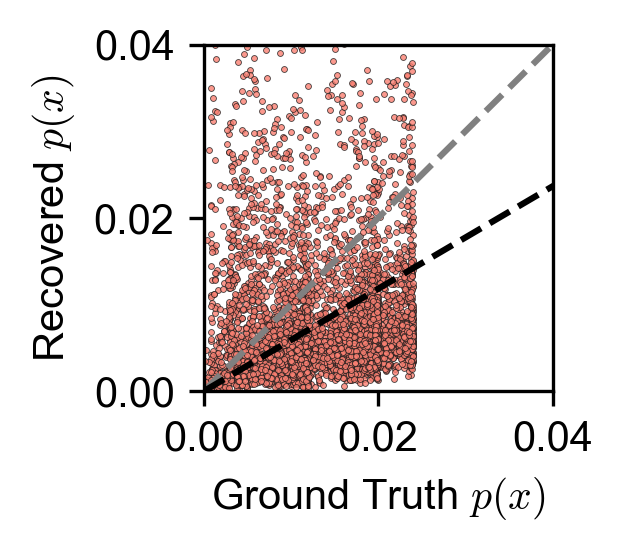

In [49]:
# Plot the samples data
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/'
filename_1 = path + 'trinormal.csv'
df_1 = pd.read_csv(filename_1, index_col=0)
samples_1 = df_1.values.flatten()

path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'
filename_2 = path + 'diffspace_trinormal.csv'
df_2 = pd.read_csv(filename_2, usecols=['bpd'])  
logp = df_2['bpd'].values.flatten()
probability_1 = np.exp(-logp)

mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_pdf = w1 * norm.pdf(samples_1, loc=mu1, scale=b1) + w2 * norm.pdf(samples_1, loc=mu2, scale=b2) + w3 * norm.pdf(samples_1, loc=mu3, scale=b3)

# sorted_indices = np.argsort(samples_1)
# samples_1_sorted = samples_1[sorted_indices]
# gaussian_pdf_sorted = gaussian_pdf[sorted_indices]
# probability_1_sorted = probability_1[sorted_indices]

# # Subsample for clarity
# gaussian_pdf_sub = gaussian_pdf_sorted#[::10]
# probability_sub = probability_1_sorted#[::10]

plt.figure(figsize=(1.5, 1.5))
plt.scatter(gaussian_pdf[:5000], probability_1[:5000], color='salmon', edgecolors=(0.1, 0.1, 0.1), linewidth=0.2, s=2, label="Scatter", alpha=0.8, zorder=-1)

# Draw y = x line
plt.plot([0, 0.4], [0, 0.4], color='gray', linestyle='--', label='y = x', zorder=0)

def line_through_origin(x, a):
    return a * x

# Fit the model
params, pcov, infodict, mesg, ier  = curve_fit(line_through_origin, gaussian_pdf, probability_1, full_output=True)
a = params[0]

# Draw y = ax line
min_val = min(gaussian_pdf.min(), probability_1.min())
max_val = max(gaussian_pdf.max(), probability_1.max())
plt.plot([min_val, max_val], [a*min_val, a*max_val], color='k', linestyle='--', label=f'y = {a:.2f}x')


# Example
corr, p_value = pearsonr(gaussian_pdf, probability_1)
print(f"Pearson Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

plt.xlim([0, 0.04])
plt.ylim([0, 0.04])
plt.yticks([0, 0.02, 0.04])
plt.xticks([0, 0.02, 0.04])
plt.xlabel("Ground Truth $p(x)$")
plt.ylabel("Recovered $p(x)$")
plt.gcf().set_dpi(300)
plt.savefig("diffspace_gt.png", dpi=300, bbox_inches='tight')

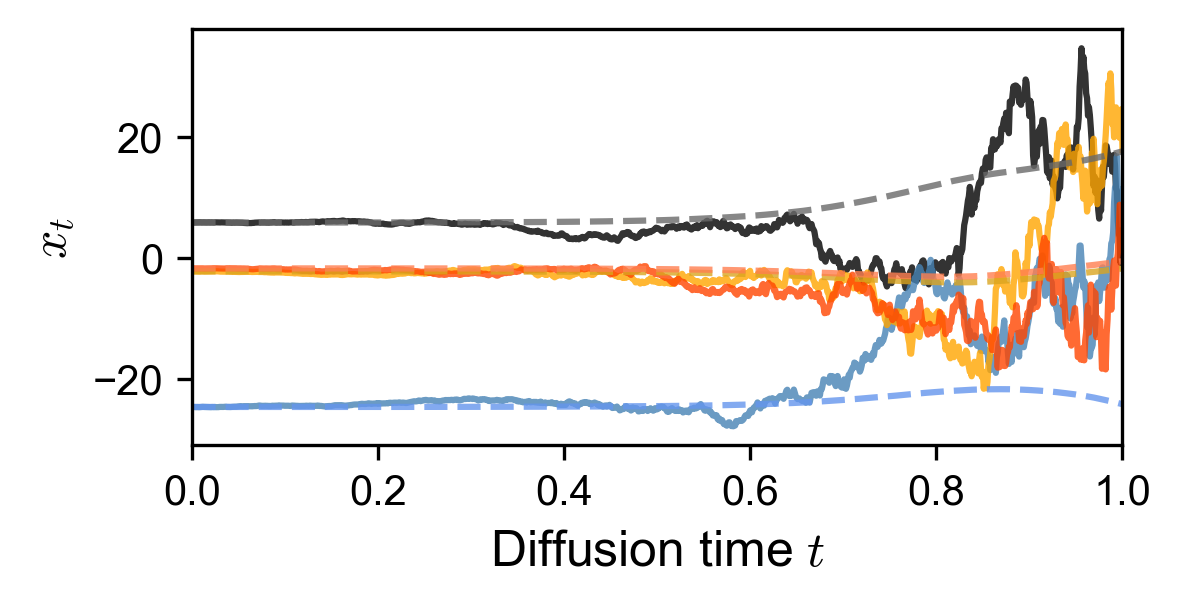

In [34]:
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/traj/'

x_values = np.linspace(0, 1, 1000)

filename_1 = 'lp1.csv'
df1 = pd.read_csv(path+filename_1)
sample_values_1 = df1['Sample'].values[::-1]

filename_2 = 'lp2.csv'
df2 = pd.read_csv(path+filename_2)
sample_values_2 = df2['Sample'].values[::-1]

filename_3 = 'lp3.csv'
df3 = pd.read_csv(path+filename_3)
sample_values_3 = df3['Sample'].values[::-1]

filename_4 = 'lp4.csv'
df4 = pd.read_csv(path+filename_4)
sample_values_4 = df4['Sample'].values[::-1]

with open('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/submit/sample_flow_path/sample_flow_path.pkl', 'rb') as f:
    sample_flow_path = pickle.load(f)

x_values_flow = np.linspace(0, 1, 100)

# Plot
plt.figure(figsize=(4, 1.8))
plt.plot(x_values, sample_values_1, color='black', alpha=0.8, label="Trajectory 1")
plt.plot(x_values, sample_values_2, color='steelblue', alpha=0.8, label="Trajectory 2")
plt.plot(x_values, sample_values_3, color='orange', alpha=0.8, label="Trajectory 3")
plt.plot(x_values, sample_values_4, color='orangered', alpha=0.8, label="Trajectory 4")
plt.plot(x_values_flow, sample_flow_path[0][:,0], color='dimgray', linestyle='--', alpha=0.8, label="Trajectory 1")
plt.plot(x_values_flow, sample_flow_path[1][:,0], color='cornflowerblue', linestyle='--', alpha=0.8, label="Trajectory 2")
plt.plot(x_values_flow, sample_flow_path[2][:,0], color='goldenrod', linestyle='--', alpha=0.8, label="Trajectory 3")
plt.plot(x_values_flow, sample_flow_path[3][:,0], color='coral', linestyle='--', alpha=0.8, label="Trajectory 4")
# plt.xticks([0, 1000], labels=['0', '1'])
# plt.yticks(fontsize=16)
plt.xlim(0, 1)
# plt.legend()
plt.xlabel('Diffusion time $t$', fontsize=12)
plt.ylabel('$x_{t}$', fontsize=12)
plt.gcf().set_dpi(300)
plt.savefig('sample_v_t.png', dpi=300, bbox_inches='tight')

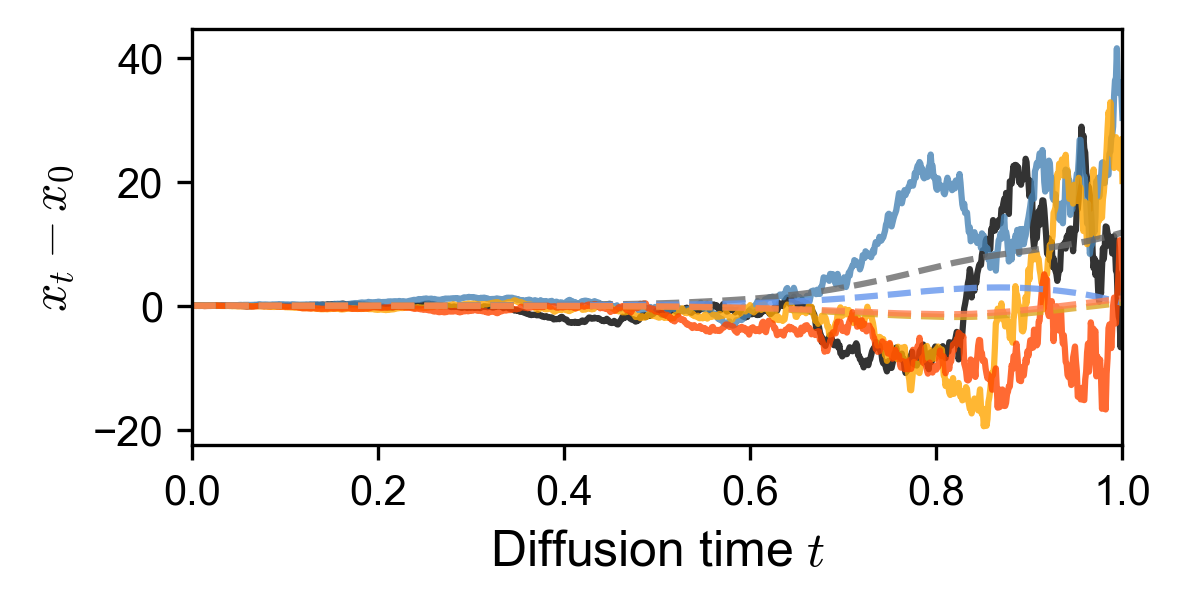

In [35]:
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/traj/'

x_values = np.linspace(0, 1, 1000)

filename_1 = 'lp1.csv'
df1 = pd.read_csv(path+filename_1)
sample_values_1 = df1['Sample'].values[::-1]

filename_2 = 'lp2.csv'
df2 = pd.read_csv(path+filename_2)
sample_values_2 = df2['Sample'].values[::-1]

filename_3 = 'lp3.csv'
df3 = pd.read_csv(path+filename_3)
sample_values_3 = df3['Sample'].values[::-1]

filename_4 = 'lp4.csv'
df4 = pd.read_csv(path+filename_4)
sample_values_4 = df4['Sample'].values[::-1]

with open('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/submit/sample_flow_path/sample_flow_path.pkl', 'rb') as f:
    sample_flow_path = pickle.load(f)

x_values_flow = np.linspace(0, 1, 100)

# Plot
plt.figure(figsize=(4, 1.8))
plt.plot(x_values, sample_values_1 - sample_values_1[0], color='black', alpha=0.8, label="Trajectory 1")
plt.plot(x_values, sample_values_2 - sample_values_2[0], color='steelblue', alpha=0.8, label="Trajectory 2")
plt.plot(x_values, sample_values_3 - sample_values_3[0], color='orange', alpha=0.8, label="Trajectory 3")
plt.plot(x_values, sample_values_4 - sample_values_4[0], color='orangered', alpha=0.8, label="Trajectory 4")
plt.plot(x_values_flow, sample_flow_path[0][:,0] - sample_flow_path[0][0,0], color='dimgray', linestyle='--', alpha=0.8, label="Trajectory 1")
plt.plot(x_values_flow, sample_flow_path[1][:,0] - sample_flow_path[1][0,0], color='cornflowerblue', linestyle='--', alpha=0.8, label="Trajectory 2")
plt.plot(x_values_flow, sample_flow_path[2][:,0] - sample_flow_path[2][0,0], color='goldenrod', linestyle='--', alpha=0.8, label="Trajectory 3")
plt.plot(x_values_flow, sample_flow_path[3][:,0] - sample_flow_path[3][0,0], color='coral', linestyle='--', alpha=0.8, label="Trajectory 4")
# plt.xticks([0, 1000], labels=['0', '1'])
# plt.yticks(fontsize=16)
plt.xlim(0, 1)
# plt.legend()
plt.xlabel('Diffusion time $t$', fontsize=12)
plt.ylabel('$x_{t} - x_{0}$', fontsize=12)
plt.gcf().set_dpi(300)
plt.savefig('delta_sample_v_t.png', dpi=300, bbox_inches='tight')

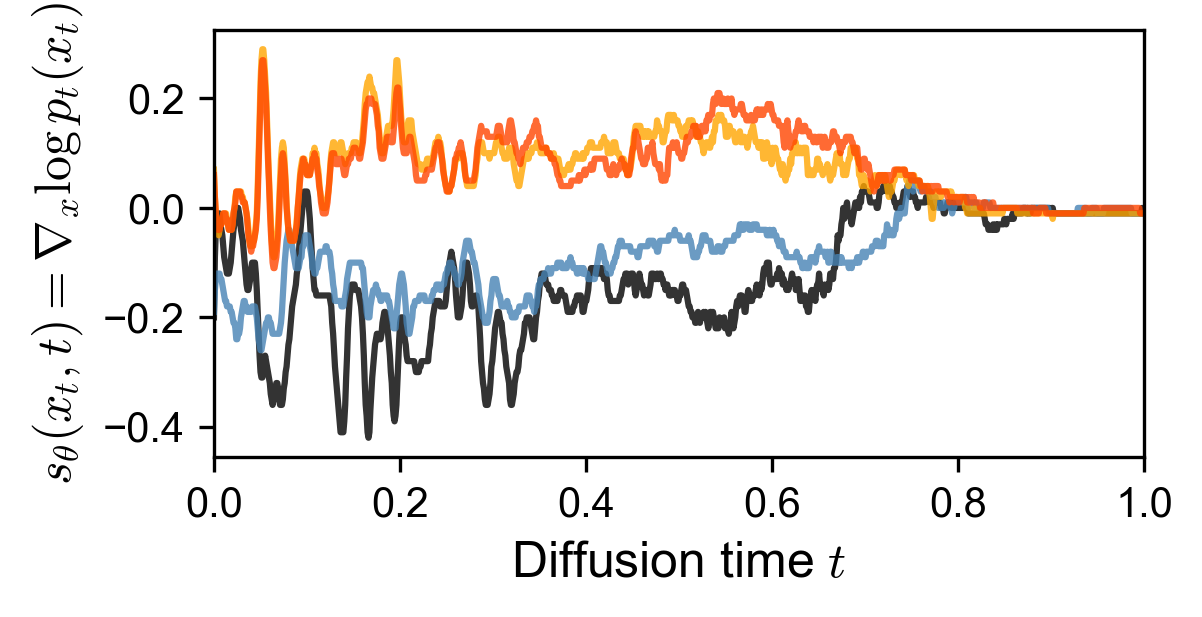

In [4]:
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'

x_values = np.linspace(0, 1, 1000)

filename_1 = 'score_lp1.csv'
df1 = pd.read_csv(path+filename_1)
sample_values_1 = df1['score_1'].values[::-1]

filename_2 = 'score_lp2.csv'
df2 = pd.read_csv(path+filename_2)
sample_values_2 = df2['score_1'].values[::-1]

filename_3 = 'score_lp3.csv'
df3 = pd.read_csv(path+filename_3)
sample_values_3 = df3['score_1'].values[::-1]

filename_4 = 'score_lp4.csv'
df4 = pd.read_csv(path+filename_4)
sample_values_4 = df4['score_1'].values[::-1]

# Plot
plt.figure(figsize=(4, 1.85))
plt.plot(x_values, sample_values_1, color='black', alpha=0.8, label="Trajectory 1")
plt.plot(x_values, sample_values_2, color='steelblue', alpha=0.8, label="Trajectory 2")
plt.plot(x_values, sample_values_3, color='orange', alpha=0.8, label="Trajectory 3")
plt.plot(x_values, sample_values_4, color='orangered', alpha=0.8, label="Trajectory 4")
#plt.xlabel('Time (Diffusion steps)')
#plt.ylabel('Score (bits/dim)')
#plt.ylabel('NLL (bits/dim)')
# plt.xticks([0, 1000], labels=['0', '1'], fontsize=16)
# plt.yticks(fontsize=16)
plt.xlim(0, 1)
# plt.legend()
plt.xlabel('Diffusion time $t$', fontsize=12)
plt.ylabel(r'$s_{\theta} (x_t,t)=\nabla_{x} \log p_{t}(x_{t})$', fontsize=12)
plt.gcf().set_dpi(300)
plt.savefig('score_v_t.png', dpi=300, bbox_inches='tight')

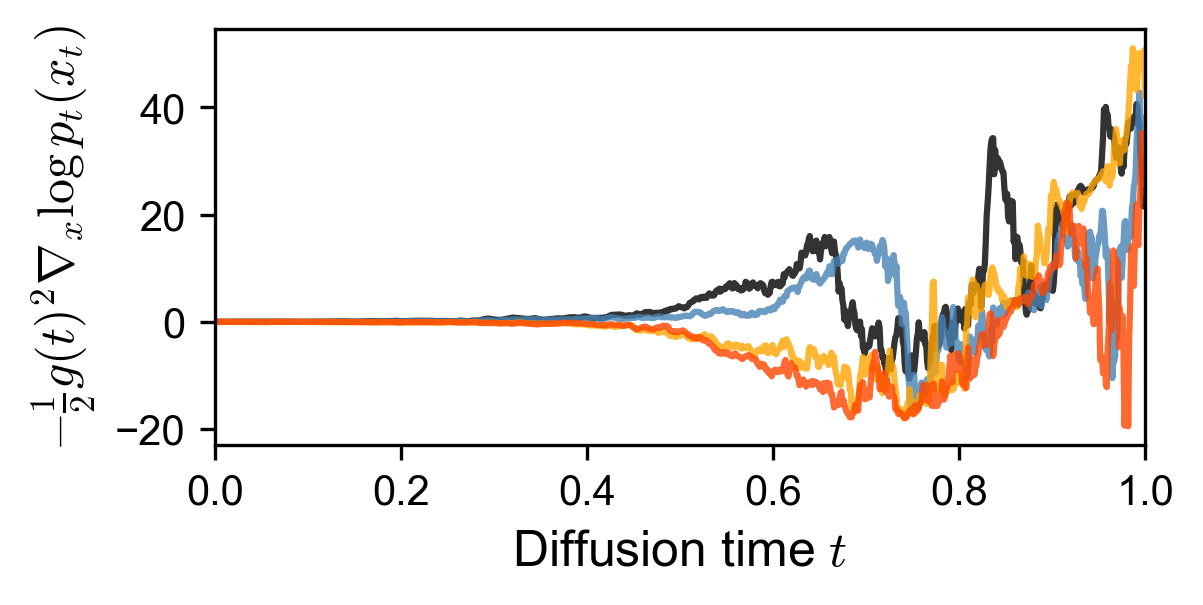

In [37]:
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/results/'

x_values = np.linspace(0, 1, 1000)

filename_1 = 'ft_lp1.csv'
df1 = pd.read_csv(path+filename_1)
sample_values_1 = df1['score_1'].values[::-1]

filename_2 = 'ft_lp2.csv'
df2 = pd.read_csv(path+filename_2)
sample_values_2 = df2['score_1'].values[::-1]

filename_3 = 'ft_lp3.csv'
df3 = pd.read_csv(path+filename_3)
sample_values_3 = df3['score_1'].values[::-1]

filename_4 = 'ft_lp4.csv'
df4 = pd.read_csv(path+filename_4)
sample_values_4 = df4['score_1'].values[::-1]

# Plot
plt.figure(figsize=(4, 1.8))
plt.plot(x_values, sample_values_1, color='black', alpha=0.8, label="Trajectory 1")
plt.plot(x_values, sample_values_2, color='steelblue', alpha=0.8, label="Trajectory 2")
plt.plot(x_values, sample_values_3, color='orange', alpha=0.8, label="Trajectory 3")
plt.plot(x_values, sample_values_4, color='orangered', alpha=0.8, label="Trajectory 4")
#plt.xlabel('Time (Diffusion steps)')
#plt.ylabel('Score (bits/dim)')
#plt.ylabel('NLL (bits/dim)')
# plt.xticks([0, 1000], labels=['0', '1'], fontsize=16)
# plt.yticks(fontsize=16)
plt.xlim(0, 1)
# plt.legend()
plt.xlabel('Diffusion time $t$', fontsize=12)
plt.ylabel(r'$-\frac{1}{2}g(t)^2 \nabla_{x} \log p_{t}(x_{t})$', fontsize=12)
plt.gcf().set_dpi(300)
plt.savefig('scaled_score_v_t.png', dpi=300, bbox_inches='tight')

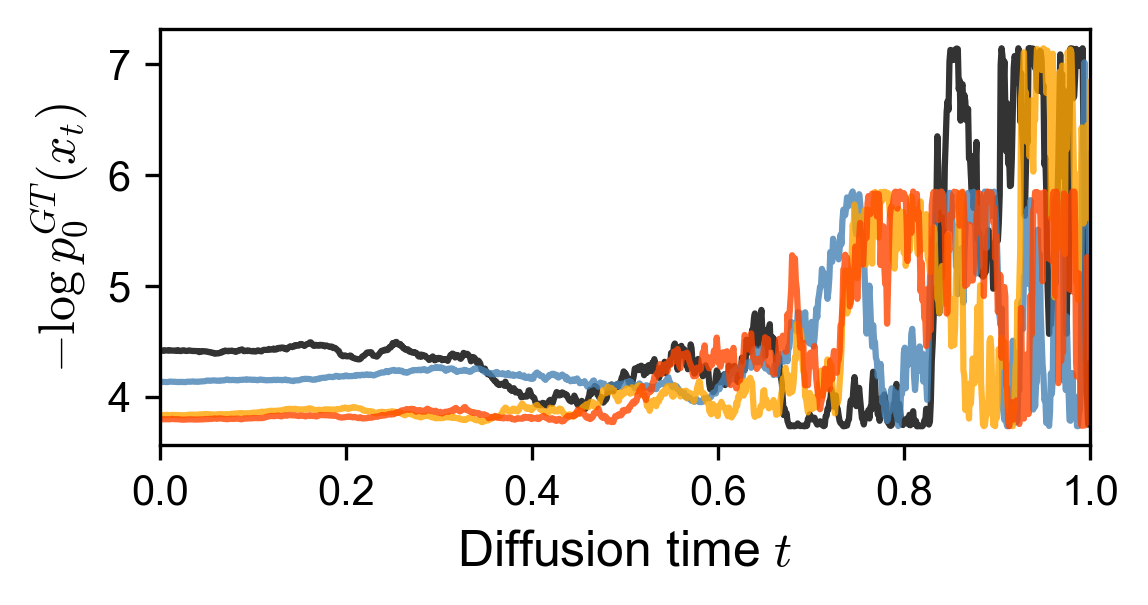

In [38]:
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/traj/'

x_values = np.linspace(0, 1, 1000)

filename_1 = 'lp1.csv'
df1 = pd.read_csv(path+filename_1)
sample_values_1 = df1['Sample'].values[::-1]

filename_2 = 'lp2.csv'
df2 = pd.read_csv(path+filename_2)
sample_values_2 = df2['Sample'].values[::-1]

filename_3 = 'lp3.csv'
df3 = pd.read_csv(path+filename_3)
sample_values_3 = df3['Sample'].values[::-1]

filename_4 = 'lp4.csv'
df4 = pd.read_csv(path+filename_4)
sample_values_4 = df4['Sample'].values[::-1]

mu1, mu2, mu3 = -30, 0, 40
b1, b2, b3 = 8.0, 5.0, 10.0
w1, w2, w3 = 0.4, 0.3, 0.3
gaussian_sample_1 = - np.log((w1 * norm.pdf(sample_values_1, loc=mu1, scale=b1) + w2 * norm.pdf(sample_values_1, loc=mu2, scale=b2) + w3 * norm.pdf(sample_values_1, loc=mu3, scale=b3)))
gaussian_sample_2 = - np.log((w1 * norm.pdf(sample_values_2, loc=mu1, scale=b1) + w2 * norm.pdf(sample_values_2, loc=mu2, scale=b2) + w3 * norm.pdf(sample_values_2, loc=mu3, scale=b3)))
gaussian_sample_3 = - np.log((w1 * norm.pdf(sample_values_3, loc=mu1, scale=b1) + w2 * norm.pdf(sample_values_3, loc=mu2, scale=b2) + w3 * norm.pdf(sample_values_3, loc=mu3, scale=b3)))
gaussian_sample_4 = - np.log((w1 * norm.pdf(sample_values_4, loc=mu1, scale=b1) + w2 * norm.pdf(sample_values_4, loc=mu2, scale=b2) + w3 * norm.pdf(sample_values_4, loc=mu3, scale=b3)))

# Plot
plt.figure(figsize=(4, 1.8))
plt.plot(x_values, gaussian_sample_1, color='black', alpha=0.8, label="Trajectory 1")
plt.plot(x_values, gaussian_sample_2, color='steelblue', alpha=0.8, label="Trajectory 2")
plt.plot(x_values, gaussian_sample_3, color='orange', alpha=0.8, label="Trajectory 3")
plt.plot(x_values, gaussian_sample_4, color='orangered', alpha=0.8, label="Trajectory 4")
# plt.xticks([0, 1000], labels=['0', '1'], fontsize=16)
# plt.yticks(fontsize=16)
#plt.xlabel('Time (Diffusion steps)')
#plt.ylabel('NLL (bits/dim)')
plt.xlim(0, 1)
# plt.legend()
plt.xlabel('Diffusion time $t$', fontsize=12)
plt.ylabel(r'$-\log p^{GT}_0(x_t)$', fontsize=12)
plt.gcf().set_dpi(300)
plt.savefig('ground_truth_e_v_t.png', dpi=300, bbox_inches='tight')